## Transfer Learning for Image Classification

In [27]:
from torchvision import datasets
dataset=datasets.ImageFolder("MLProjectData/train")
print(dataset.classes)

['my_dog', 'not_my_dog']


#### Step 4: Imports

In [54]:
import os
import copy
import time
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets,transforms
from torchvision import models
from torch.utils.data import DataLoader
from PIL import Image

## Step 5: Device Cell

In [57]:
device=torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("using device:",device)

using device: cpu


## Step 6: Transforms Cell

In [60]:
train_transform=transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2,contrast=0.2,saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],
                         [0.229,0.224,0.225])
])
val_test_transform=transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],
                         [0.229,0.224,0.225])
])

## Step 7:Load the Datasets

In [63]:
data_dir="MLProjectData"
train_dataset=datasets.ImageFolder(os.path.join(data_dir,"train"),transform=train_transform)
val_dataset=datasets.ImageFolder(os.path.join(data_dir,"val"),transform=val_test_transform)
test_dataset=datasets.ImageFolder(os.path.join(data_dir,"test"),transform=val_test_transform)

## Step 8: Show a few sample images

## Step 9:Load pretrained ResNet18

In [73]:
from torchvision import models
import torch.nn as nn

model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

# Freeze pretrained layers
for param in model.parameters():
    param.requires_grad = False

# Replace classifier for 2 classes
num_features = model.fc.in_features
model.fc = nn.Linear(num_features, 2)

## Step 10: Loss and optimizer

In [76]:
criterion=nn.CrossEntropyLoss()
optimizer=optim.Adam(model.fc.parameters(),lr=0.001)

## Step 11: Training function

In [104]:
def train_model(model, train_loader, val_loader, criterion, optimizer, num_epochs=5):
    best_model_wts=copy.deepcopy(model.state_dict())
    best_val_acc=0.0
    train_losses=[]
    val_losses=[]
    train_accuracies=[]
    val_accuracies=[]

    for epoch in range(num_epochs):
        print(f"Epoch{epoch+1}/{num_epochs}")
        print("-"*30)

        #Training phase
        model.train()
        running_loss=0.0
        running_corrects=0.0

        for inputs,labels in train_loader:
            inputs=inputs.to(device)
            labels=labels.to(device)

            optimizer.zero_grad()

            outputs=model(inputs)
            _, preds=torch.max(outputs,1)
            loss=criterion(outputs,labels)

            loss.backward()
            optimizer.step()

            running_loss+=loss.item()*inputs.size(0)
            running_corrects+=torch.sum(preds==labels.data)
        epoch_train_loss=running_loss/len(train_loader.dataset)
        epoch_train_acc=running_corrects.double().item()/len(train_loader.dataset)

        #Validation phase
        model.eval()
        running_loss=0.0
        running_corrects=0

        with torch.no_grad():
            for inputs,labels in val_loader:
                inputs=inputs.to(device)
                labels=labels.to(device)

                outputs=model(inputs)
                _,preds=torch.max(outputs,1)
                loss=criterion(outputs,labels)

                running_loss+=loss.item()*inputs.size(0)
                running_corrects+=torch.sum(preds==labels.data)
            epoch_val_loss=running_loss/len(val_loader.dataset)
            epoch_val_acc=running_corrects.double().item()/len(val_loader.dataset)

            train_losses.append(epoch_train_loss)
            val_losses.append(epoch_val_loss)
            train_accuracies.append(epoch_train_acc)
            val_accuracies.append(epoch_val_acc)

            print(f"Train Loss: {epoch_train_loss:.4f} | Train Acc: {epoch_train_acc:.4f}")
            print(f"Val Loss:   {epoch_val_loss:.4f} | Val Acc:   {epoch_val_acc:.4f}")

            if epoch_val_acc > best_val_acc:
                best_val_acc = epoch_val_acc
                best_model_wts = copy.deepcopy(model.state_dict())

            print()
    
        model.load_state_dict(best_model_wts)
    return model, train_losses, val_losses, train_accuracies, val_accuracies                     

## Step 12: Train

In [121]:
from torch.utils.data import DataLoader
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)

model,train_losses,val_losses,train_accuracies,val_accuracies=train_model(
    model,train_loader,val_loader,criterion,optimizer,num_epochs=10
)

Epoch1/10
------------------------------
Train Loss: 0.3434 | Train Acc: 0.8750
Val Loss:   0.3538 | Val Acc:   1.0000

Epoch2/10
------------------------------
Train Loss: 0.4286 | Train Acc: 0.7750
Val Loss:   0.3513 | Val Acc:   0.9000

Epoch3/10
------------------------------
Train Loss: 0.3063 | Train Acc: 0.9000
Val Loss:   0.3304 | Val Acc:   1.0000

Epoch4/10
------------------------------
Train Loss: 0.3557 | Train Acc: 0.8250
Val Loss:   0.3395 | Val Acc:   1.0000

Epoch5/10
------------------------------
Train Loss: 0.3221 | Train Acc: 0.9500
Val Loss:   0.3316 | Val Acc:   0.9000

Epoch6/10
------------------------------
Train Loss: 0.2961 | Train Acc: 0.9500
Val Loss:   0.3318 | Val Acc:   1.0000

Epoch7/10
------------------------------
Train Loss: 0.3450 | Train Acc: 0.9000
Val Loss:   0.3320 | Val Acc:   1.0000

Epoch8/10
------------------------------
Train Loss: 0.3440 | Train Acc: 0.8750
Val Loss:   0.3300 | Val Acc:   1.0000

Epoch9/10
------------------------------

## Step 13: Plot loss and accuracy

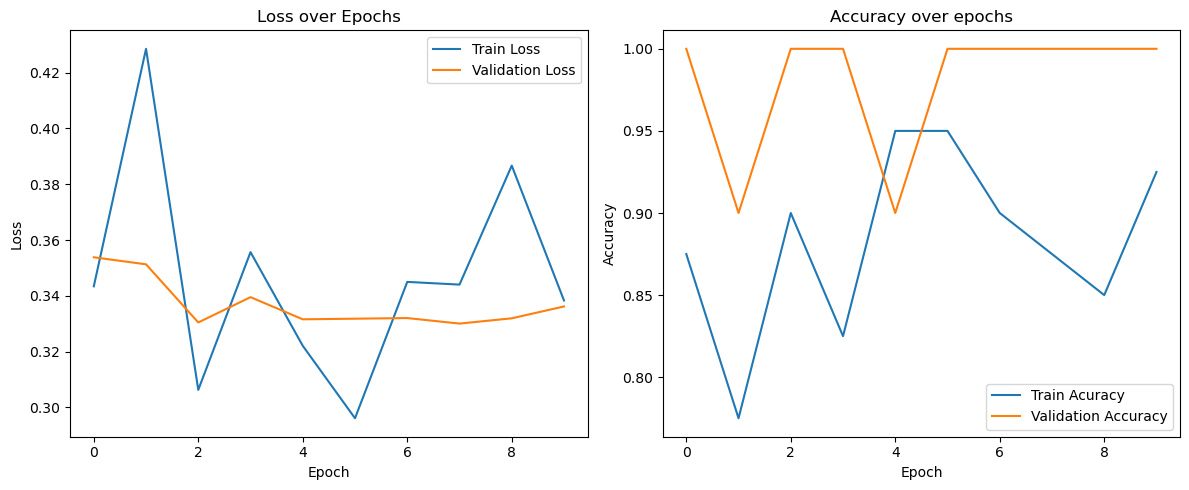

In [124]:
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(train_losses,label="Train Loss")
plt.plot(val_losses,label="Validation Loss")
plt.title("Loss over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.subplot(1,2,2)
plt.plot(train_accuracies,label="Train Acuracy")
plt.plot(val_accuracies, label="Validation Accuracy")
plt.title("Accuracy over epochs")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.tight_layout()
plt.show()

## Step 14: Test Evaluation

In [127]:
def evaluate_model(model,test_loader):
    model.eval()
    running_corrects=0
    total=0

    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs=inputs.to(device)
            labels=labels.to(device)

            outputs=model(inputs)
            _,preds=torch.max(outputs,1)

            running_corrects+=torch.sum(preds==labels.data)
            total+=labels.size(0)

    test_acc=running_corrects.double().item()/total
    return test_acc
test_accuracy=evaluate_model(model,test_loader)
print(f"Test Accuracy:{test_accuracy:.4f}")

Test Accuracy:0.7778


## Step 15: Save the model

In [129]:
torch.save(model.state_dict(), "best_model.pth")
print("Model saved as best_model.pth")

Model saved as best_model.pth


In [7]:
import os

print("train contents:", os.listdir("MLProjectData/train"))
print("my_dog contents:", os.listdir("MLProjectData/train/my_dog"))
print("not_my_dog contents:", os.listdir("MLProjectData/train/not_my_dog"))

train contents: ['.ipynb_checkpoints', 'my_dog', 'not_my_dog']
my_dog contents: ['.ipynb_checkpoints', 'Sushi (20).jpeg', 'Sushi(1).jpeg', 'Sushi(10).jpeg', 'Sushi(11).jpg', 'Sushi(12).jpg', 'Sushi(13).jpg', 'Sushi(14).jpg', 'Sushi(15).jpg', 'Sushi(16).jpg', 'Sushi(17).jpg', 'Sushi(18).jpg', 'Sushi(19).jpg', 'Sushi(2).jpeg', 'Sushi(3).jpeg', 'Sushi(4).jpeg', 'Sushi(5).jpeg', 'Sushi(6).jpeg', 'Sushi(7).jpeg', 'Sushi(8).jpeg', 'Sushi(9).jpeg']
not_my_dog contents: ['andrea-lightfoot-FdFxAsNtpjk-unsplash.jpg', 'brad-starkey-gLACRbgxzpI-unsplash.jpg', 'flouffy-g2FtlFrc164-unsplash.jpg', 'ja-san-miguel-_-QQuvAwQ-0-unsplash.jpg', 'jamie-street-MoDcnVRN5JU-unsplash.jpg', 'joe-caione-qO-PIF84Vxg-unsplash.jpg', 'julio-bernal-WLGx0fKFSeI-unsplash.jpg', 'karsten-winegeart-JGkGlJlgR1Y-unsplash.jpg', 'karsten-winegeart-lQ8WvR54MOU-unsplash.jpg', 'karsten-winegeart-nwe2qgAhT4k-unsplash.jpg', 'karsten-winegeart-oU6KZTXhuvk-unsplash.jpg', 'karsten-winegeart-Qb7D1xw28Co-unsplash.jpg', 'kieran-white-NKN

In [25]:
import os
import shutil

folders_to_check = [
    "MLProjectData/train",
    "MLProjectData/val",
    "MLProjectData/test",
    "MLProjectData/train/my_dog",
    "MLProjectData/train/not_my_dog",
    "MLProjectData/val/my_dog",
    "MLProjectData/val/not_my_dog",
    "MLProjectData/test/my_dog",
    "MLProjectData/test/not_my_dog",
]

for folder in folders_to_check:
    checkpoint_path = os.path.join(folder, ".ipynb_checkpoints")
    if os.path.exists(checkpoint_path):
        shutil.rmtree(checkpoint_path)
        print(f"Deleted: {checkpoint_path}")

Deleted: MLProjectData/train\.ipynb_checkpoints
Deleted: MLProjectData/val\.ipynb_checkpoints
Deleted: MLProjectData/test\.ipynb_checkpoints
Deleted: MLProjectData/train/my_dog\.ipynb_checkpoints


In [69]:
print(model)

NameError: name 'model' is not defined